In [1]:
# %% [markdown]
# # Imports
# 

# %%
from pathlib import Path
import json
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind
import statsmodels.api as sm

PROJECT_DIR = Path("./") #Path.home() / "Documents" / "GitHub" / "CORI_dev"
SRC_DIR = PROJECT_DIR / "code/src"
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

from src.data import (
    TREATMENT_COLUMNS,
    cohort_audit,
    load_clinical,
    load_cohort,
    load_sites,
    load_treatment,
    merge_columns,
    collapse_cmr_columns,
    read_csv,
)
 
from src.metrics import (
    baseline_table, 
)
 

SEED = 20260714
np.random.seed(SEED)

# %% [markdown]
# # Data paths

# %%
DATA_DIR = PROJECT_DIR / "data"
CLEAN_DIR = DATA_DIR / "CLEAN_COHORTS_21JUL"

OUTPUT_DIR = PROJECT_DIR / "outputs_refactored"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models"
SCORE_DIR = OUTPUT_DIR / "scores"
QC_DIR = OUTPUT_DIR / "qc"

for directory in [TABLE_DIR, FIGURE_DIR, MODEL_DIR, SCORE_DIR, QC_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


COHORT_FILES = {
    "D1":  "./data/CORI_input_files_21Jul/D1_CORI_cancer_development_train_ready_f1024.csv",
    "D2": "./data/CORI_input_files_21Jul/D2_CORI_cancer_heldout_train_ready_f1024.csv",
    "D3": "./data/CORI_input_files_21Jul/D3_MMACEv2_never_cancer_development_train_ready_f1024.csv",
    "D4": "./data/CORI_input_files_21Jul/D4_MMACEv2_never_cancer_heldout_train_ready_f1024.csv",
    "D6": "./data/CORI_input_files_21Jul/D6_CMR_subset_train_ready_f1024.csv",
} 

# Preserve the historical variable name so downstream cells remain unchanged.
MEANPOOL_FILES = COHORT_FILES

CLINICAL_FILE = DATA_DIR / "final_df_HTN_DB_Status.csv"
TREATMENT_FILE = DATA_DIR / "risk_score_df_final_shared_22April_2026.csv"
CANCER_SITE_FILE = DATA_DIR / "CORI_allcancer_8Jan2026.csv"
CMR_FILE = DATA_DIR / "cardiac_mri.csv"
HANDCRAFTED_FILE = DATA_DIR / "H1_handcrafted_subject_level_features_cached.csv"

DEEP_FEATURES = [f"f{i}" for i in range(1024)]
FEATURE_VIEW_COLUMN = "feature_prefix_used"
FEATURE_SOURCE_COLUMN = "source_name"

CLINICAL_VARIABLES = ["age", "female", "height", "Diabetes", "HTN"]
PRIMARY_ADJUSTMENT = ["age", "female", "Diabetes", "HTN"]
MATCH_VARIABLES = ["age", "female", "height"]
CANCER_SITE_COLUMNS = [
    "DigestiveCancer_present", "RespiCancer_present", "BreastCancer_present",
    "FemRepoCancer_present", "MaleRepoCancer_present", "UrinaryTractCancer_present",
    "EndocrineCancer_present", "HeamatoCancer_present", "InsituCancer_present",
    "LipOralCancer_present", "BoneCancer_present", "SkinCancer_present",
    "MesotheliumCancer_present", "EyeCNSCancer_present", "SecondaryCancer_present",
    "UnknownCancer_present",
]


TUNING_K = [10, 15, 20]
TUNING_PENALTIES = [0.001, 0.01, 0.05, 0.1]
TUNING_FOLDS = 3
TUNING_REPEATS = 3
TUNING_RULE = "one_se"

BOOTSTRAPS = 1000
MATCHED_REPETITIONS = 200
CRUDE_MATCHED_REPETITIONS = 200

RUN_FULL_LEARNING_CURVE = True
RUN_ALL_REPRESENTATIONS = False
RUN_HANDCRAFTED = True
RUN_CMR = True
RUN_CROSSFIT_MEDIATION = True

# Records the explicit decision to retain both pre-existing
# RETFound-derived feature provenance groups in the train-ready cohorts.
ALLOW_MIXED_RETFOUND_VIEWS = True


# %%
def save_table(df, name):
    path = TABLE_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(path)
    return df


def add_groups(df, score_column, thresholds, prefix):
    out = df.copy()
    out[f"{prefix}_high"] = (out[score_column] > thresholds["median"]).astype(int)
    out[f"{prefix}_tertile"] = pd.cut(
        out[score_column],
        [-np.inf, thresholds["tertile_1"], thresholds["tertile_2"], np.inf],
        labels=["Low", "Middle", "High"],
        include_lowest=True,
    ).astype(str)
    return out


def score_thresholds(values):
    values = np.asarray(values, dtype=float)
    return {
        "median": float(np.quantile(values, 0.50)),
        "tertile_1": float(np.quantile(values, 1 / 3)),
        "tertile_2": float(np.quantile(values, 2 / 3)),
    }


def rank_features_by_group(X, Y, features):
    """Rank features by how differently they are distributed between two Y groups.

    X is a DataFrame containing the candidate feature columns, Y is a
    0/1 group label aligned to X's index (e.g. cancer vs. non-cancer).
    For each feature this runs a Welch two-sample t-test between the
    Y==0 and Y==1 rows, and fits a univariate logistic regression of Y on
    the standardized feature to get a beta (log-odds per SD) that is
    comparable across features on different scales. Rows are sorted by
    |t-statistic| descending, so the most group-discriminative features
    come first.
    """
    y = pd.to_numeric(pd.Series(Y, index=X.index), errors="raise")
    groups = sorted(y.dropna().unique().tolist())
    if groups != [0, 1]:
        raise ValueError(f"Y must be a binary 0/1 group label, found: {groups}")

    rows = []
    for feature in features:
        values = pd.to_numeric(X[feature], errors="coerce")
        mask = values.notna() & y.notna()
        v, g = values[mask], y[mask]
        x0, x1 = v[g == 0], v[g == 1]

        if len(x0) < 2 or len(x1) < 2 or v.std(ddof=0) == 0:
            rows.append({
                "feature": feature, "t_stat": np.nan, "abs_t_stat": np.nan,
                "p_value": np.nan, "beta": np.nan,
                "n_group0": len(x0), "n_group1": len(x1),
            })
            continue

        t_stat, p_value = ttest_ind(x1, x0, equal_var=False)

        z = (v - v.mean()) / v.std(ddof=0)
        design = sm.add_constant(z)
        try:
            beta = float(sm.Logit(g, design).fit(disp=0).params[feature])
        except Exception:
            beta = np.nan

        rows.append({
            "feature": feature,
            "t_stat": float(t_stat),
            "abs_t_stat": abs(float(t_stat)),
            "p_value": float(p_value),
            "beta": beta,
            "n_group0": len(x0),
            "n_group1": len(x1),
        })

    return (
        pd.DataFrame(rows)
        .sort_values("abs_t_stat", ascending=False)
        .reset_index(drop=True)
    )


# %% [markdown]
# # Load data

# %%
# ============================================================
# Load train-ready RETFound-derived cohorts
# ============================================================

meanpool = {
    cohort: load_cohort(COHORT_FILES[cohort], DEEP_FEATURES)
    for cohort in COHORT_FILES.keys()
}

# Harmonize the authoritative cancer indicator and retain provenance.
for cohort, cohort_df in meanpool.items():
    if "A_cancer_primary" in cohort_df.columns:
        cohort_df["A_cancer"] = pd.to_numeric(
            cohort_df["A_cancer_primary"],
            errors="raise",
        ).astype(int)

    if FEATURE_VIEW_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_VIEW_COLUMN] = "unknown"

    if FEATURE_SOURCE_COLUMN not in cohort_df.columns:
        cohort_df[FEATURE_SOURCE_COLUMN] = "unknown"

    cohort_df[FEATURE_VIEW_COLUMN] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )
    cohort_df[FEATURE_SOURCE_COLUMN] = (
        cohort_df[FEATURE_SOURCE_COLUMN]
        .fillna("unknown")
        .astype(str)
        .str.strip()
    )

    # Retained for optional provenance-adjusted sensitivity analyses.
    cohort_df["feature_view_emb2"] = (
        cohort_df[FEATURE_VIEW_COLUMN]
        .eq("emb2_f")
        .astype(int)
    )


# ============================================================
# Merge approved external metadata exactly as before
# ============================================================

clinical = load_clinical(CLINICAL_FILE)
treatment = load_treatment(TREATMENT_FILE)
sites = load_sites(CANCER_SITE_FILE, CANCER_SITE_COLUMNS)

for cohort in ["D1", "D2", "D3", "D4", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], clinical)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], treatment)

for cohort in ["D1", "D2", "D6"]:
    meanpool[cohort] = merge_columns(meanpool[cohort], sites)

meanpool["D1"]["split"] = "Development"
meanpool["D2"]["split"] = "Held-out"
meanpool["D3"]["split"] = "Development"
meanpool["D4"]["split"] = "Held-out"


# %%
cancer_all = pd.concat([meanpool["D1"], meanpool["D2"]], ignore_index=True)
table_1 = baseline_table(
    cancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)
# "Table_01_baseline_characteristics_D1_D2")


time_col = "time_years"
event_col = "Y_mace"

Noncancer_all = pd.concat([meanpool["D3"], meanpool["D4"]], ignore_index=True)
table_1 = baseline_table(
    Noncancer_all,
    group_column="split",
    continuous=["age", "height"],
    categorical=["female", "Diabetes", "HTN", "Y_mace"],
)


# %%

def preprocess_features(train_df, test_df, test2_df, test3_df, candidate, var_threshold=0.01, corr_threshold=0.9, verbose=True):
    for col in candidate:
        p1 = train_df[col].quantile(0.01)
        p99 = train_df[col].quantile(0.99)
        train_df[col] = train_df[col].clip(p1, p99)
        test_df[col] = test_df[col].clip(p1, p99)
        test2_df[col] = test2_df[col].clip(p1, p99)
        test3_df[col] = test3_df[col].clip(p1, p99)

    mean_vals = train_df[candidate].mean()
    std_vals = train_df[candidate].std()

    train_df[candidate] = (train_df[candidate] - mean_vals) / std_vals
    test_df[candidate] = (test_df[candidate] - mean_vals) / std_vals
    test2_df[candidate] = (test2_df[candidate] - mean_vals) / std_vals
    test3_df[candidate] = (test3_df[candidate] - mean_vals) / std_vals
    
    var = train_df[candidate].var()
    candidate = var[var > var_threshold].index.tolist()

    if verbose:
        print("After variance filtering:", len(candidate))

    corr = train_df[candidate].corr().abs()
    upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    to_drop = [c for c in upper.columns if any(upper[c] > corr_threshold)]
    candidate = [c for c in candidate if c not in to_drop]

    if verbose:
        print("After correlation filtering:", len(candidate))

    return train_df, test_df, test2_df, test3_df, candidate, mean_vals, std_vals

d1_coriPreProcess , d2_coriPreProcess , d3_coriPreProcess ,d4_coriPreProcess , Cori_filtered_features, mean_vals, std_vals = preprocess_features(meanpool["D1"], meanpool["D2"], meanpool["D3"], meanpool["D4"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)

d3_MMACEPreProcess , d4_MMACEPreProcess , d1_MMACEPreProcess , d2_MMACEPreProcess , MMACE_filtered_features, mean_vals, std_vals = preprocess_features(meanpool["D3"], meanpool["D4"], meanpool["D1"], meanpool["D2"],
                                                                                     DEEP_FEATURES, var_threshold=0.1, 
                                                                                     corr_threshold=0.8, verbose=True)



# %%
# cori_cohort_dict = {
#     "D1": d1_coriPreProcess,
#     "D2": d2_coriPreProcess,
#     "D4": d4_coriPreProcess,
# }

# mmace_cohort_dict = {
#     "D3": d3_MMACEPreProcess,
#     "D4": d4_MMACEPreProcess,
#     "D2": d2_MMACEPreProcess,
# }

meanpool['D1_cori'] = d1_coriPreProcess
meanpool['D2_cori'] = d2_coriPreProcess
meanpool['D3_cori'] = d3_coriPreProcess
meanpool['D4_cori'] = d4_coriPreProcess

meanpool['D1_mmace'] = d1_MMACEPreProcess
meanpool['D2_mmace'] = d2_MMACEPreProcess
meanpool['D3_mmace'] = d3_MMACEPreProcess
meanpool['D4_mmace'] = d4_MMACEPreProcess

# %%
# 'eid' is a patient identifier, not a feature -- it was never standardized in
# preprocess_features (only DEEP_FEATURES is) and its raw scale (~1e6+) was
# swamping the reconstruction loss (and hence the shared gradient signal) by
# many orders of magnitude relative to the O(1) task losses.
train_eid = pd.concat([d1_coriPreProcess['eid'], d3_coriPreProcess['eid']], ignore_index=True).to_numpy()
train_X_df = pd.concat([d1_coriPreProcess[DEEP_FEATURES],
                     d3_coriPreProcess [DEEP_FEATURES]],
                    ignore_index=True) 

train_X = train_X_df.to_numpy()


# Cancer status is a KNOWN grouping variable here (D1=cancer cohort, D3=never-cancer
# cohort), not a task to predict. Route the single MACE label to exactly one branch
# per row via NaN-masking -- branch 1 sees only cancer patients, branch 2 only
# non-cancer patients -- reusing the same missing-label mechanism MultiTaskDataset
# already uses for genuinely missing labels.
train_cancer_group = np.array([1] * len(d1_coriPreProcess) + [0] * len(d3_coriPreProcess))
train_mace = np.array(d1_coriPreProcess['Y_mace'].tolist() + d3_coriPreProcess['Y_mace'].tolist(), dtype=float)
train_Y1 = np.where(train_cancer_group == 1, train_mace, np.nan)  # branch 1: MACE | cancer
train_Y2 = np.where(train_cancer_group == 0, train_mace, np.nan)  # branch 2: MACE | non-cancer

train_df = pd.DataFrame(train_X)
train_df['Y_cancer'] = train_cancer_group
train_df['Y_mace'] = train_mace

print("Train MACE|cancer branch counts:", np.bincount(train_mace[train_cancer_group == 1].astype(int)))
print("Train MACE|non-cancer branch counts:", np.bincount(train_mace[train_cancer_group == 0].astype(int)))

test_eid = pd.concat([d2_coriPreProcess['eid'], d4_coriPreProcess['eid']], ignore_index=True).to_numpy()
test_X = pd.concat([d2_coriPreProcess[DEEP_FEATURES],
                    d4_coriPreProcess [DEEP_FEATURES]],
                   ignore_index=True).to_numpy()

test_cancer_group = np.array([1] * len(d2_coriPreProcess) + [0] * len(d4_coriPreProcess))
test_mace = np.array(d2_coriPreProcess['Y_mace'].tolist() + d4_coriPreProcess['Y_mace'].tolist(), dtype=float)
test_Y1 = np.where(test_cancer_group == 1, test_mace, np.nan)  # branch 1: MACE | cancer
test_Y2 = np.where(test_cancer_group == 0, test_mace, np.nan)  # branch 2: MACE | non-cancer

test_df = pd.DataFrame(test_X)
test_df['Y_cancer'] = test_cancer_group
test_df['Y_mace'] = test_mace

print("Test MACE|cancer branch counts:", np.bincount(test_mace[test_cancer_group == 1].astype(int)))
print("Test MACE|non-cancer branch counts:", np.bincount(test_mace[test_cancer_group == 0].astype(int)))




After variance filtering: 1024
After correlation filtering: 946
After variance filtering: 1024
After correlation filtering: 149
Train MACE|cancer branch counts: [1856  300]
Train MACE|non-cancer branch counts: [12811  1348]
Test MACE|cancer branch counts: [2100  335]
Test MACE|non-cancer branch counts: [13302  1461]


In [53]:

import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
from sklearn.linear_model import LogisticRegression
from scipy.stats import pointbiserialr


def rank_features(X, y):
    """
    Parameters
    ----------
    X : pandas.DataFrame
        Rows are samples, columns are features.
    y : array-like
        Binary group labels.

    Returns
    -------
    pandas.DataFrame
        Columns:
        - feature
        - t_stat
        - p_value
        - beta
    """
    y = np.asarray(y)
    groups = np.unique(y)

    if len(groups) != 2:
        raise ValueError("y must contain exactly two groups.")

    mask1 = y == groups[0]
    mask2 = y == groups[1]

    results = []

    for feature in X.columns:
        x1 = X.loc[mask1, feature]
        x2 = X.loc[mask2, feature]

        t_stat, p_value = ttest_ind(
            x1,
            x2,
            equal_var=False,
            nan_policy="omit"
        )

        # Logistic regression using this feature alone
        model = LogisticRegression(max_iter=1000)
        model.fit(X[[feature]], y)
        beta = model.coef_[0, 0]
        
        # correlation
        # Point-biserial correlation
        corr, corr_p = pointbiserialr(y, X[feature])

        results.append({
            "feature": feature,
            "t_stat": t_stat,
            "p_value": p_value,
            "beta": beta,
            "correlation": corr,
            "correlation_p": corr_p,
            "abs_t": abs(t_stat)
        })

    results = pd.DataFrame(results)

    # Rank by p-value, then absolute t-statistic
    results = results.sort_values(
        ["p_value", "abs_t"],
        ascending=[True, False]
    ).drop(columns="abs_t").reset_index(drop=True)

    return results



In [54]:
# train_df = pd.DataFrame(train_X)
# train_df['Y_cancer'] = train_cancer_group
# train_df['Y_mace'] = train_mace

cancer_results = rank_features(train_X_df, train_cancer_group)
print(cancer_results.head())

mace_results = rank_features(train_X_df, train_mace)
print(mace_results.head())

# print len of noth
print("Len of cancer resuls " , len(cancer_results))
print("Len of mace_results resuls " , len(mace_results))


  feature      t_stat  p_value      beta  correlation  correlation_p
0    f737  152.843676      0.0 -1.357267    -0.719582            0.0
1    f370  151.793580      0.0 -1.375019    -0.711307            0.0
2      f6  144.974799      0.0 -1.320926    -0.713830            0.0
3    f578  144.788126      0.0 -1.325510    -0.721389            0.0
4    f771  143.446304      0.0 -1.313960    -0.714299            0.0
  feature     t_stat       p_value      beta  correlation  correlation_p
0    f260  16.299805  6.500079e-56 -0.287114    -0.161826   3.834918e-96
1    f689  16.177520  3.558091e-55 -0.291321    -0.157667   2.663979e-91
2     f80 -16.113661  9.071334e-55  0.282853     0.158959   8.625468e-93
3     f12  15.761723  1.252346e-52 -0.280776    -0.153856   5.580360e-87
4    f183  15.663261  4.600640e-52 -0.282194    -0.148133   1.066704e-80
Len of cancer resuls  1024
Len of mace_results resuls  1024


In [73]:

# do FDR on p-values
from statsmodels.stats.multitest import fdrcorrection


cancer_results['abs_beta'] = cancer_results['beta'].abs()
cancer_results['abs_correlation'] = cancer_results['correlation'].abs()
cancer_results['abs_t_stat'] = cancer_results['t_stat'].abs()
cancer_results["fdr_p_value"] = fdrcorrection(cancer_results["p_value"])[1] 

mace_results['abs_beta'] = mace_results['beta'].abs()
mace_results['abs_correlation'] = mace_results['correlation'].abs()
mace_results['abs_t_stat'] = mace_results['t_stat'].abs()
mace_results["fdr_p_value"] = fdrcorrection(mace_results["p_value"])[1] 

In [83]:
threshold_percentile = 0.9

beta_threshold = cancer_results['abs_beta'].quantile(threshold_percentile)
tstat_threshold = cancer_results['abs_t_stat'].quantile(threshold_percentile)
corr_threshold = cancer_results['abs_correlation'].quantile(threshold_percentile)

selected_cancer_results = cancer_results[(cancer_results['fdr_p_value']<0.0001) * (cancer_results['abs_correlation'] > corr_threshold) ].sort_values("abs_beta") #.head(100)
selected_cancer_results = selected_cancer_results[(selected_cancer_results['fdr_p_value']<0.0001) * (selected_cancer_results['abs_t_stat'] > tstat_threshold) * (selected_cancer_results['abs_beta'] > beta_threshold) ].sort_values("abs_beta") #.head(100)
# selected_cancer_results = selected_cancer_results[(selected_cancer_results['fdr_p_value']<0.001) ].sort_values("abs_correlation") #.head(100)
selected_cancer_results

,feature,t_stat,p_value,beta,correlation,correlation_p,abs_beta,fdr_p_value,abs_correlation,abs_t_stat
99,f721,123.569608,0.0,-1.231673,-0.704336,0.0,1.231673,0.0,0.704336,123.569608
100,f866,123.408720,0.0,-1.232546,-0.702794,0.0,1.232546,0.0,0.702794,123.408720
89,f507,124.193579,0.0,-1.232609,-0.711882,0.0,1.232609,0.0,0.711882,124.193579
91,f775,124.068895,0.0,-1.233604,-0.703059,0.0,1.233604,0.0,0.703059,124.068895
88,f940,-124.579254,0.0,1.234034,0.709402,0.0,1.234034,0.0,0.709402,124.579254
...,...,...,...,...,...,...,...,...,...,...
5,f51,143.324733,0.0,-1.314256,-0.715077,0.0,1.314256,0.0,0.715077,143.324733
2,f6,144.974799,0.0,-1.320926,-0.713830,0.0,1.320926,0.0,0.713830,144.974799
3,f578,144.788126,0.0,-1.325510,-0.721389,0.0,1.325510,0.0,0.721389,144.788126
0,f737,152.843676,0.0,-1.357267,-0.719582,0.0,1.357267,0.0,0.719582,152.843676


In [84]:

beta_threshold = mace_results['abs_beta'].quantile(threshold_percentile)
tstat_threshold = mace_results['abs_t_stat'].quantile(threshold_percentile)
corr_threshold = mace_results['abs_correlation'].quantile(threshold_percentile)

selected_mace_results = mace_results[(mace_results['fdr_p_value']<0.0001) * (mace_results['abs_correlation'] > corr_threshold) ].sort_values("abs_beta") #.head(100)
selected_mace_results = selected_mace_results[(selected_mace_results['fdr_p_value']<0.0001) * (selected_mace_results['abs_t_stat'] > tstat_threshold) * (selected_mace_results['abs_beta'] > beta_threshold) ].sort_values("abs_beta") #.head(100)
# selected_cancer_results = selected_cancer_results[(selected_cancer_results['fdr_p_value']<0.001) ].sort_values("abs_correlation") #.head(100)
selected_mace_results

,feature,t_stat,p_value,beta,correlation,correlation_p,abs_beta,fdr_p_value,abs_correlation,abs_t_stat
89,f644,14.904151,1.456269e-47,-0.263089,-0.141214,1.957747e-73,0.263089,1.650024e-46,0.141214,14.904151
79,f328,14.930961,9.999036e-48,-0.263765,-0.140220,2.021792e-72,0.263765,1.267321e-46,0.140220,14.930961
92,f247,14.895389,1.633694e-47,-0.263894,-0.140961,3.555412e-73,0.263894,1.798820e-46,0.140961,14.895389
61,f79,15.040394,2.331080e-48,-0.264298,-0.142340,1.362810e-74,0.264298,3.850041e-47,0.142340,15.040394
64,f657,15.016962,3.101957e-48,-0.264661,-0.139969,3.635842e-72,0.264661,4.886775e-47,0.139969,15.016962
...,...,...,...,...,...,...,...,...,...,...
3,f12,15.761723,1.252346e-52,-0.280776,-0.153856,5.580360e-87,0.280776,3.206007e-50,0.153856,15.761723
4,f183,15.663261,4.600640e-52,-0.282194,-0.148133,1.066704e-80,0.282194,9.422111e-50,0.148133,15.663261
2,f80,-16.113661,9.071334e-55,0.282853,0.158959,8.625468e-93,0.282853,3.096349e-52,0.158959,16.113661
0,f260,16.299805,6.500079e-56,-0.287114,-0.161826,3.834918e-96,0.287114,6.656081e-53,0.161826,16.299805


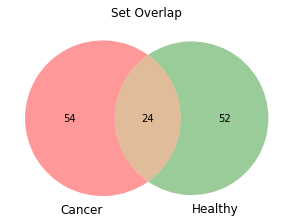

{'unique_to_list1': 54, 'unique_to_list2': 52, 'intersection': 24, 'union': 130, 'jaccard_index': 0.18461538461538463}


In [85]:
from matplotlib import pyplot as plt
from matplotlib_venn import venn2

def plot_set_overlap(list1, list2, labels=("List 1", "List 2")):
    s1, s2 = set(list1), set(list2)

    plt.figure(figsize=(5, 5))
    venn2([s1, s2], set_labels=labels)
    plt.title("Set Overlap")
    plt.show()

    return {
        "unique_to_list1": len(s1 - s2),
        "unique_to_list2": len(s2 - s1),
        "intersection": len(s1 & s2),
        "union": len(s1 | s2),
        "jaccard_index": len(s1 & s2) / len(s1 | s2)
    }
    
stats = plot_set_overlap(
        selected_cancer_results['feature'],
        selected_mace_results['feature'],
        labels=("Cancer", "Healthy")
)

print(stats)

In [88]:
overlap = set(selected_cancer_results['feature']) & set(selected_mace_results['feature'])
cancerOnly = set(selected_cancer_results['feature']) - set(selected_mace_results['feature'])
Maceonly =  set(selected_mace_results['feature']) - set(selected_cancer_results['feature'])


len(overlap) , len(cancerOnly) ,len(Maceonly)

(24, 54, 52)

In [90]:
print(overlap)
print(cancerOnly)
print(Maceonly)

{'f370', 'f501', 'f355', 'f940', 'f323', 'f657', 'f51', 'f74', 'f620', 'f811', 'f509', 'f6', 'f242', 'f275', 'f689', 'f832', 'f762', 'f438', 'f737', 'f424', 'f792', 'f867', 'f183', 'f18'}
{'f513', 'f771', 'f507', 'f250', 'f443', 'f666', 'f976', 'f339', 'f95', 'f240', 'f721', 'f836', 'f907', 'f385', 'f727', 'f537', 'f686', 'f604', 'f731', 'f866', 'f497', 'f729', 'f944', 'f110', 'f459', 'f350', 'f89', 'f584', 'f22', 'f704', 'f534', 'f347', 'f775', 'f523', 'f955', 'f263', 'f340', 'f10', 'f177', 'f137', 'f557', 'f542', 'f72', 'f431', 'f284', 'f699', 'f121', 'f1011', 'f578', 'f34', 'f113', 'f441', 'f194', 'f682'}
{'f603', 'f405', 'f717', 'f80', 'f217', 'f1021', 'f471', 'f156', 'f477', 'f328', 'f176', 'f521', 'f354', 'f260', 'f196', 'f986', 'f935', 'f185', 'f369', 'f322', 'f546', 'f767', 'f693', 'f440', 'f586', 'f427', 'f644', 'f416', 'f869', 'f552', 'f941', 'f927', 'f873', 'f247', 'f587', 'f989', 'f967', 'f5', 'f561', 'f79', 'f556', 'f725', 'f826', 'f188', 'f285', 'f929', 'f12', 'f909', 'f5